# Gaussian Random Projection (GRP)

This notebook applies **Gaussian Random Projection (GRP)** to the processed TCGA PANCAN
gene-expression dataset. The objective is to evaluate GRP as a data-independent, random
linear dimension reduction method for multiclass cancer classification.

Model performance is evaluated using **Repeated Stratified 5-Fold Cross-Validation** with
**5 repetitions** (25 train/test splits). To prevent data leakage, feature standardization
and the GRP projection are fitted exclusively on the training data within each
cross-validation split.

In addition to predictive performance, this notebook evaluates the computational
efficiency, representation quality (pairwise distance preservation), and reconstruction
ability of GRP.

## Workflow

1. Load the processed dataset.
2. Import the required libraries.
3. Define the cross-validation strategy:
   - Repeated Stratified 5-Fold Cross-Validation (5 folds × 5 repetitions).
4. Define the numbers of projected dimensions:
   - n_components = [5, 10, 25, 50]
5. For each value of n_components:
   - For each cross-validation split:
     - Split the data into training and test sets.
     - Fit StandardScaler on the training data.
     - Transform the training and test data.
     - Fit GaussianRandomProjection on the standardized training data.
     - Transform the training and test data.
     - Train the Logistic Regression classifier.
     - Generate predictions.
     - Compute and store: Accuracy, Macro Precision, Macro Recall, Macro F1 Score,
       Macro ROC-AUC.
     - Record: GRP fit time, GRP transform time.
     - Reconstruct the standardized test data using the Moore-Penrose pseudo-inverse
       of the projection matrix.
     - Compute and store the reconstruction error (MSE).
6. Aggregate the results across all cross-validation splits for each value of
   n_components by computing their mean and standard deviation.
7. Save the evaluation results:
   - grp_classification_summary.csv
   - grp_reconstruction_summary.csv
   - grp_runtime_summary.csv
8. Evaluate representation quality using the full processed dataset:
   - Standardize the entire dataset.
   - Fit GRP for each value of n_components.
   - Compute pairwise distances in the original and projected feature spaces.
   - Compute the Pearson correlation between original and projected pairwise
     distances (distance preservation).
   - Generate and save the distance preservation plot.

## 1. Data and Imports

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.random_projection import GaussianRandomProjection
from sklearn.metrics import pairwise_distances

random_state = 42

In [2]:
# Set project root
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

In [3]:
# Import custom evaluation functions
from src.evaluation import evaluate_classification, summarize_results

In [4]:
# Load the processed dataset
X = pd.read_csv(project_root / "data" / "processed" / "X_processed.csv")
X = X.iloc[:, 1:]
y = pd.read_csv(project_root / "data" / "processed" / "y_processed.csv",index_col=0).iloc[:, 0]

## 2. Define Experimental Settings

In [5]:
# Cross-validation strategy
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=random_state)

In [6]:
# Numbers of principal components to evaluate
n_components_list = [5, 10, 25, 50]

In [7]:
# Classifier
classifier = LogisticRegression(max_iter=1000, random_state=random_state)

## 3. GRP Classification Pipeline

In [8]:
# Start total timer
total_start = time.perf_counter()

# Initialize result storage

# CLassification Performance
classification_results = {}
classification_summary = {}

# Reconstruction
reconstruction_results = {}
reconstruction_summary = {}

# Runtime
runtime_results = {}
runtime_summary = None

# Evaluate GRP using repeated stratified cross-validation
for n_components in n_components_list:

    print(f"\nEvaluating grp with {n_components} components")
    
    # Start timer for this value of n_components
    component_start = time.perf_counter()

    # Store results for all CV splits
    classification_split_results = []
    reconstruction_split_results = []

    fit_times = []
    transform_times = []
    grp_process_times = []

    # Cross-validation loop
    for split_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

        # Split data
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Standardisation
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # GRP
        grp = GaussianRandomProjection(n_components=n_components,random_state=random_state)

        # Fit time
        fit_start = time.perf_counter()

        X_train_grp = grp.fit_transform(X_train_scaled)

        fit_time = time.perf_counter() - fit_start
        fit_times.append(fit_time)

        # Transform time
        transform_start = time.perf_counter()

        X_test_grp = grp.transform(X_test_scaled)

        transform_time = time.perf_counter() - transform_start
        transform_times.append(transform_time)

        # GRP process time (fit + transform)
        grp_process_time = fit_time + transform_time
        grp_process_times.append(grp_process_time)

        # Classification

        classifier.fit(X_train_grp, y_train)
        
        y_pred = classifier.predict(X_test_grp)
        y_prob = classifier.predict_proba(X_test_grp)

        metrics = evaluate_classification(
            y_test,
            y_pred,
            y_prob,
        )

        metrics["Split"] = split_idx
        classification_split_results.append(metrics)

        # Reconstruction

        components = grp.components_
        projection_pinv = np.linalg.pinv(components.T)
        
        X_test_reconstructed = X_test_grp @ projection_pinv
        X_test_reconstructed = scaler.inverse_transform(X_test_reconstructed)

        reconstruction_error = np.mean(
            (X_test.to_numpy() - X_test_reconstructed) ** 2
        )

        reconstruction_split_results.append(
            {
                "Split": split_idx,
                "Reconstruction MSE": reconstruction_error,
            }
        )


    # Store classification results
    classification_results[n_components] = pd.DataFrame(classification_split_results)
    
    classification_summary[n_components] = summarize_results([{k: v for k, v in m.items() if k != "Split"} for m in classification_split_results])

    # Store reconstruction results
    reconstruction_results[n_components] = pd.DataFrame(reconstruction_split_results)

    reconstruction_summary[n_components] = (
        reconstruction_results[n_components]
        .drop(columns="Split")
        .agg(["mean", "std"])
        .T
        .rename(columns={"mean": "Mean", "std": "Std"})
    )

    # Runtime
    component_end = time.perf_counter()

    runtime_results[n_components] = {
        "Fit Time Mean (s)": np.mean(fit_times),
        "Fit Time Std (s)": np.std(fit_times, ddof=1),
        "Transform Time Mean (s)": np.mean(transform_times),
        "Transform Time Std (s)": np.std(transform_times, ddof=1),
        "GRP Process Time Mean (s)": np.mean(grp_process_times),
        "GRP Process Time Std (s)": np.std(grp_process_times, ddof=1),
        "Total Runtime (s)": component_end - component_start,
    }

    print(
        f"grp ({n_components:>2} components): "
        f"{runtime_results[n_components]['Total Runtime (s)']:.2f} seconds"
    )


# Runtime summary
runtime_summary = pd.DataFrame(runtime_results).T
runtime_summary.index.name = "n_components"

# Total runtime
total_end = time.perf_counter()

print(f"\nTotal runtime: {(total_end - total_start)/60:.2f} minutes")


Evaluating grp with 5 components
grp ( 5 components): 82.17 seconds

Evaluating grp with 10 components
grp (10 components): 90.28 seconds

Evaluating grp with 25 components
grp (25 components): 113.36 seconds

Evaluating grp with 50 components
grp (50 components): 94.97 seconds

Total runtime: 6.35 minutes


## 4. Results Summary

In [9]:
# Combine classification summaries
classification_summary_df = pd.concat(
    classification_summary,
    names=["n_components", "Metric"]
)

print(classification_summary_df)

                                  Mean       Std
n_components Metric                             
5            Accuracy         0.728581  0.023130
             Macro Precision  0.711866  0.027027
             Macro Recall     0.703395  0.023193
             Macro F1         0.703946  0.022666
             Macro ROC AUC    0.921331  0.010115
10           Accuracy         0.803716  0.025239
             Macro Precision  0.807335  0.028156
             Macro Recall     0.804397  0.029788
             Macro F1         0.803670  0.028279
             Macro ROC AUC    0.952607  0.009352
25           Accuracy         0.893865  0.026049
             Macro Precision  0.888718  0.030667
             Macro Recall     0.892495  0.025444
             Macro F1         0.889012  0.027235
             Macro ROC AUC    0.980229  0.008311
50           Accuracy         0.962042  0.013248
             Macro Precision  0.957807  0.015182
             Macro Recall     0.965467  0.011716
             Macro F

In [10]:
# Combine reconstruction summaries

reconstruction_summary_df = pd.concat(
    reconstruction_summary,
    names=["n_components", "Metric"]
)

print(reconstruction_summary_df)

                                     Mean       Std
n_components Metric                                
5            Reconstruction MSE  1.787700  0.025375
10           Reconstruction MSE  1.787501  0.025394
25           Reconstruction MSE  1.786514  0.025411
50           Reconstruction MSE  1.783980  0.025427


In [11]:
print(runtime_summary)

              Fit Time Mean (s)  Fit Time Std (s)  Transform Time Mean (s)  \
n_components                                                                 
5                      0.061567          0.013438                 0.010191   
10                     0.064921          0.004885                 0.010694   
25                     0.081648          0.005172                 0.013374   
50                     0.114419          0.005138                 0.015986   

              Transform Time Std (s)  GRP Process Time Mean (s)  \
n_components                                                      
5                           0.001340                   0.071758   
10                          0.001080                   0.075614   
25                          0.002303                   0.095022   
50                          0.001262                   0.130405   

              GRP Process Time Std (s)  Total Runtime (s)  
n_components                                               
5       

In [12]:
# Save Results
# Output directories

metrics_dir = Path("../results/metrics")
timings_dir = Path("../results/timings")

metrics_dir.mkdir(parents=True, exist_ok=True)
timings_dir.mkdir(parents=True, exist_ok=True)

# Save summaries

classification_summary_df.to_csv(
    metrics_dir / "grp_classification_summary.csv"
)

reconstruction_summary_df.to_csv(
    metrics_dir / "grp_reconstruction_summary.csv"
)

runtime_summary.to_csv(
    timings_dir / "grp_runtime_summary.csv"
)

print("Results saved successfully.")

Results saved successfully.


# 5. Representation Quality

In [13]:
# Standardize the full dataset
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [14]:
# Figure Directories
figure_dir = Path("../figures/GRP")
figure_dir.mkdir(parents=True, exist_ok=True)

In [15]:
# Distance Preservation
# Representation quality results
distance_results = []

# Evaluate distance preservation for each number of components
for n_components in n_components_list:

    grp = GaussianRandomProjection(
        n_components=n_components,
        random_state=random_state,
    )

    X_grp = grp.fit_transform(X_scaled)

    # Compute pairwise distances
    original_distances = pairwise_distances(X_scaled)
    projected_distances = pairwise_distances(X_grp)

    # Correlation between original and projected distances
    distance_correlation = np.corrcoef(
        original_distances.ravel(),
        projected_distances.ravel(),
    )[0, 1]

    distance_results.append({
        "n_components": n_components,
        "Distance Correlation": distance_correlation,
    })

# Save results
distance_df = pd.DataFrame(distance_results)

distance_df.to_csv(
    metrics_dir / "grp_distance_preservation.csv",
    index=False,
)

print(distance_df)

   n_components  Distance Correlation
0             5              0.444087
1            10              0.581715
2            25              0.757538
3            50              0.856329


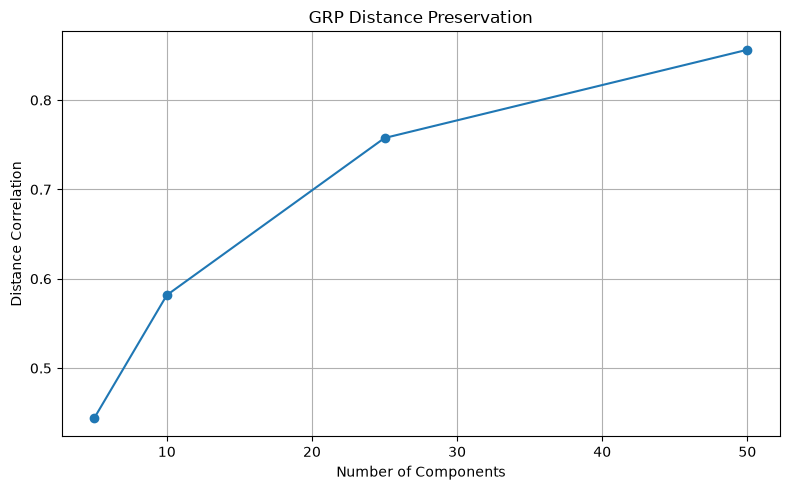

In [16]:
# Distance Preservation Plot
plt.figure(figsize=(8,5))

plt.plot(
    distance_df["n_components"],
    distance_df["Distance Correlation"],
    marker="o",
)

plt.xlabel("Number of Components")
plt.ylabel("Distance Correlation")
plt.title("GRP Distance Preservation")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    figure_dir / "distance_preservation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()